In [1]:
%load_ext autoreload
%autoreload 2

import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent / "src"))


In [2]:
from gecco import GeCCoConfig, GeCCoPipeline
from gecco.preprocess import DataPreprocessor
from gecco.tree import ModuleTreeBuilder, ModuleNode
from gecco.visualize import plot_module_tree, plot_node_genes

In [3]:
adata = sc.read_h5ad('../datasets/adata_sim.h5ad')


In [4]:
cfg = GeCCoConfig()
preprocessor = DataPreprocessor(cfg)
pre = preprocessor.run(adata)

<Axes: >

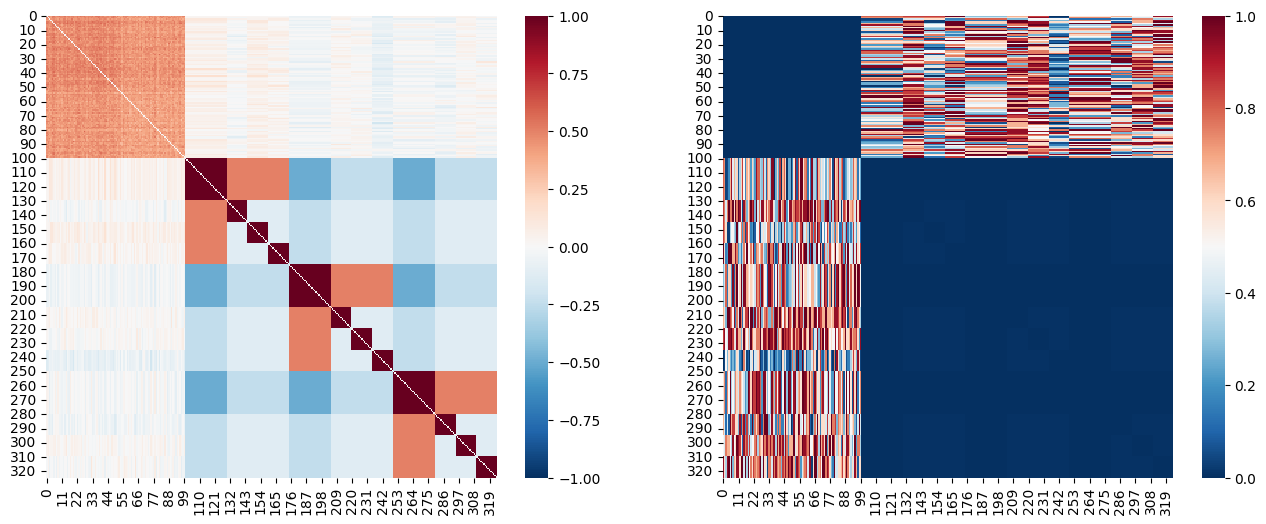

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16,6))
sns.heatmap(pre.phi, ax=axes[0], cmap="RdBu_r", vmin=-1, vmax=1)
sns.heatmap(pre.fdr, ax=axes[1], cmap="RdBu_r", vmin=0, vmax=1)

In [6]:
pipeline = GeCCoPipeline(cfg)
result = pipeline.run(adata, pre)

图已保存至: ../outputs/module_tree.png


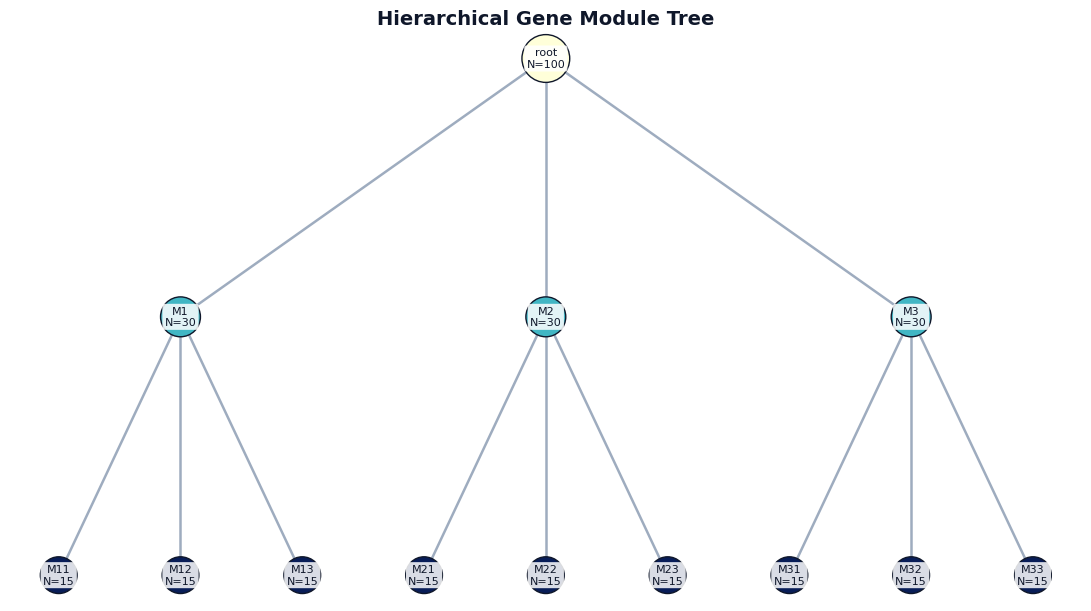

In [7]:
plot_module_tree(result.tree_root, "../outputs/module_tree.png")

图已保存至: ../outputs/node_genes.png


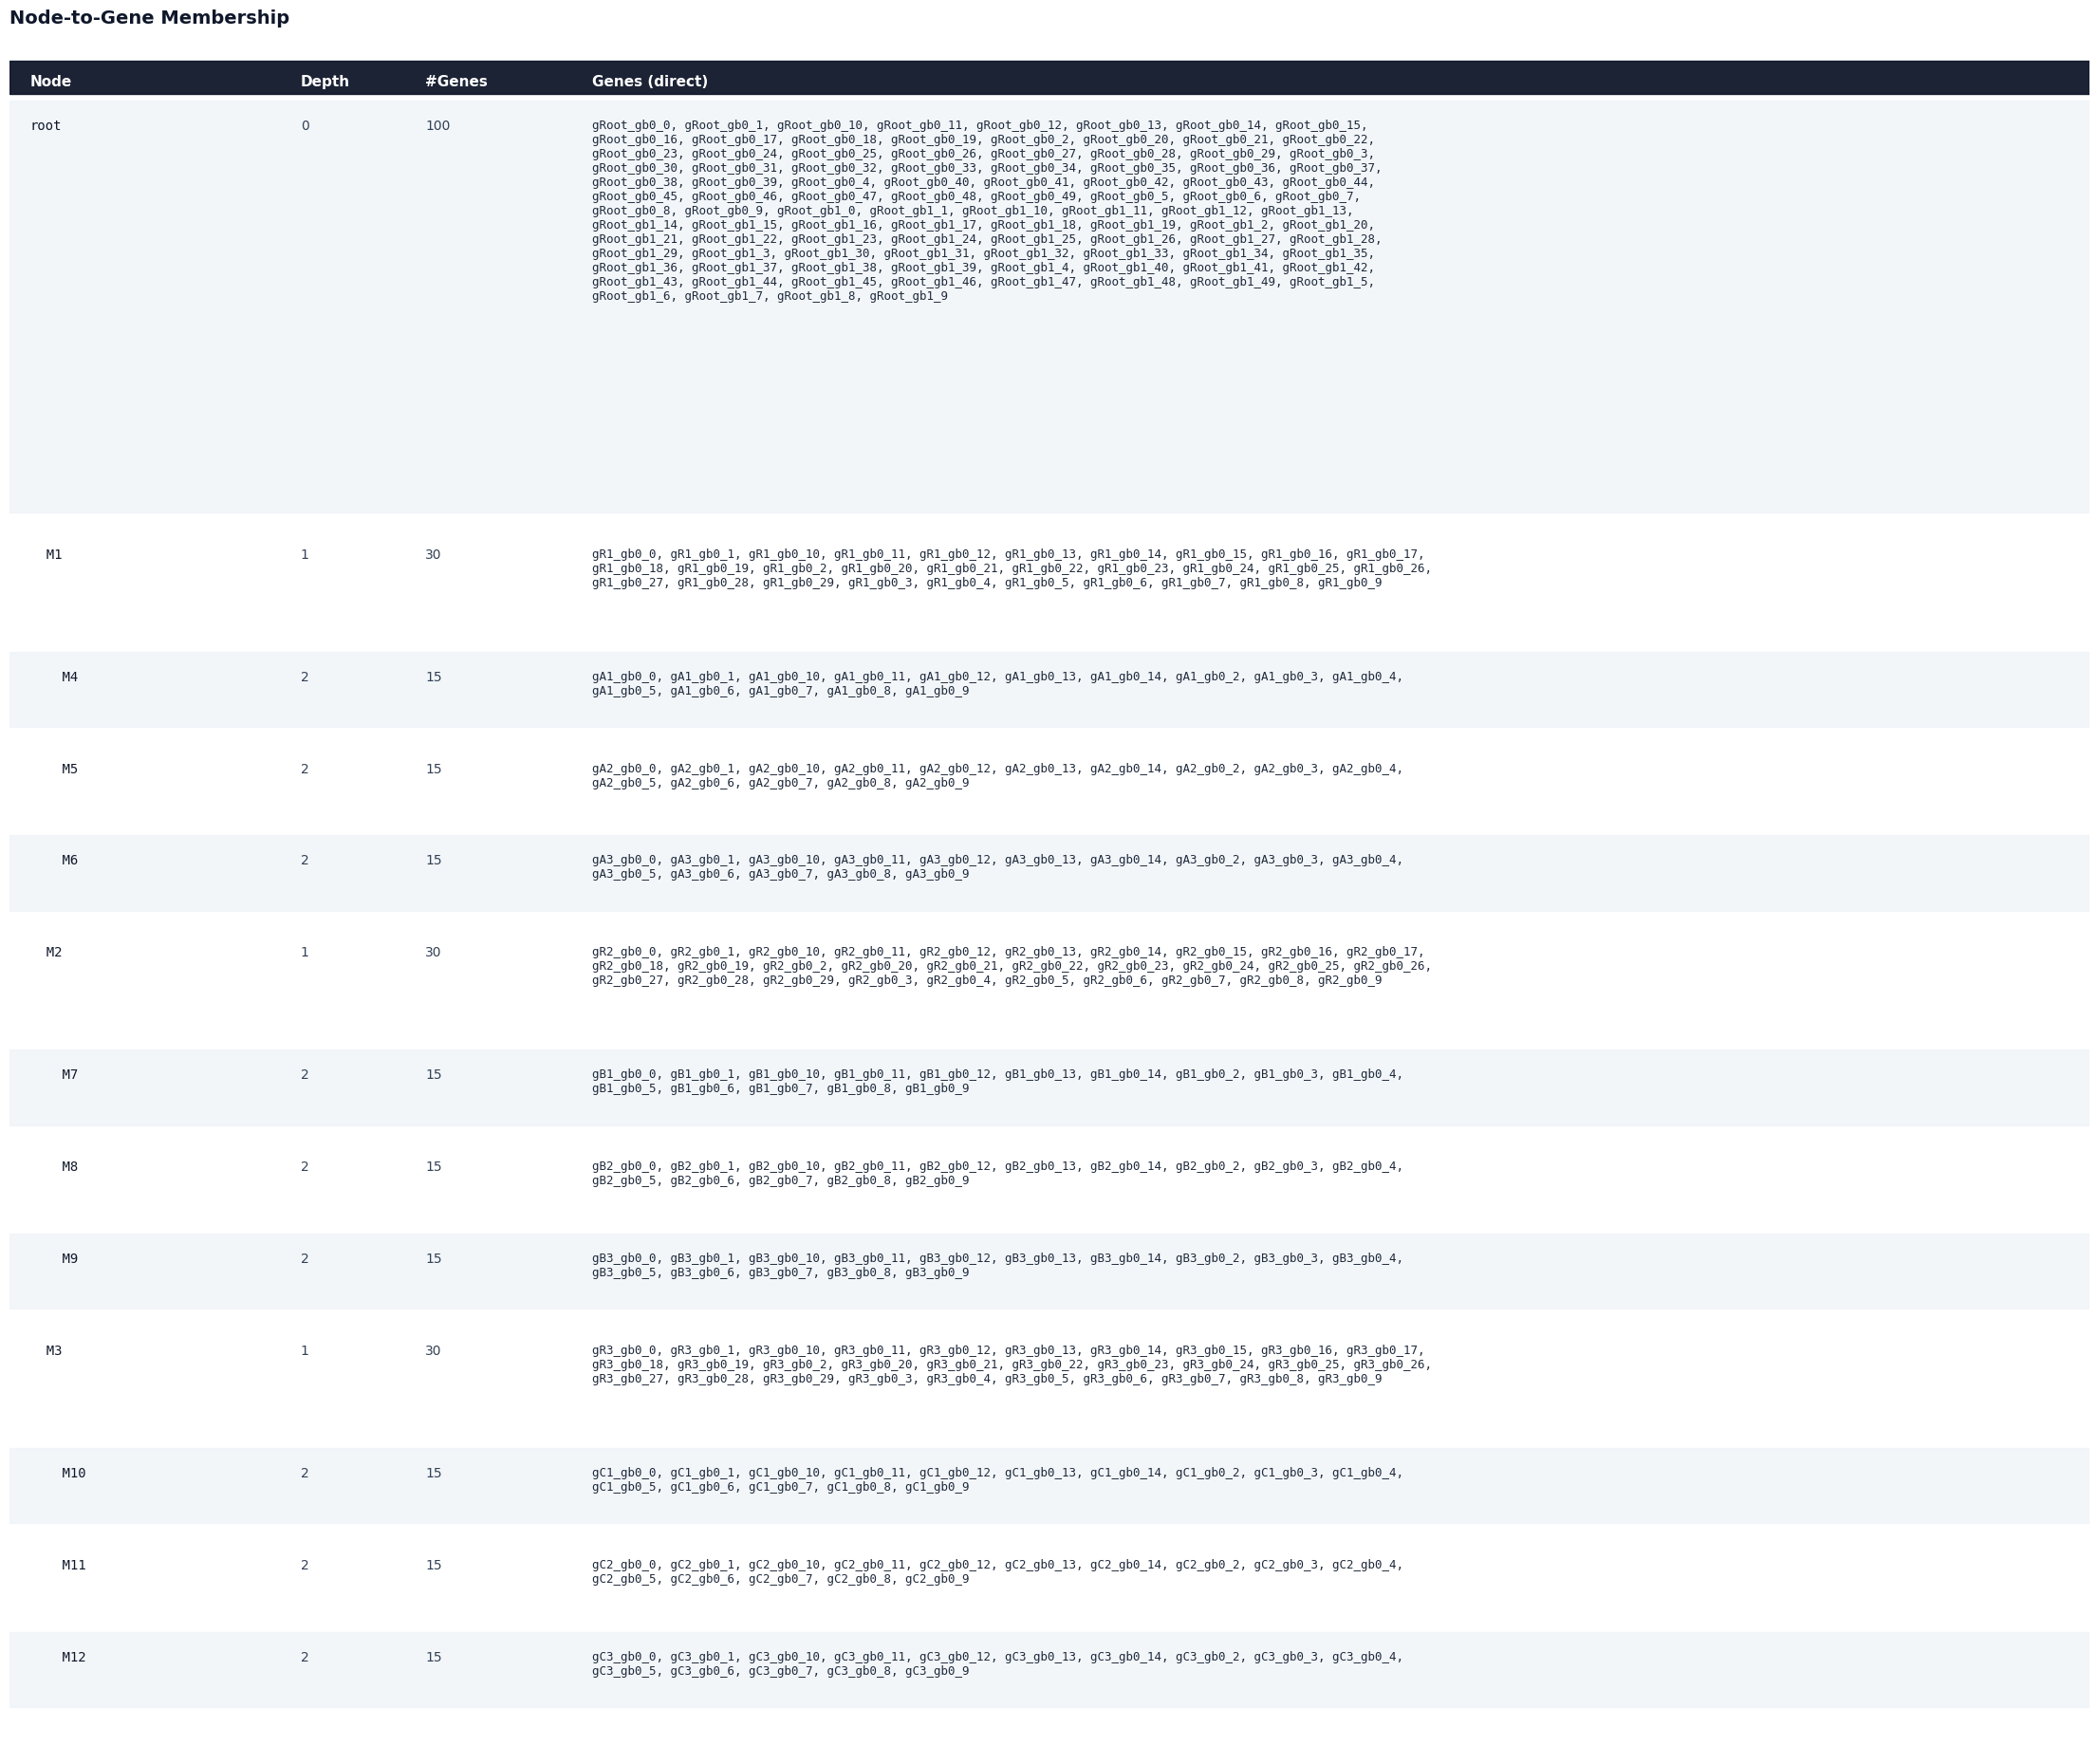

In [8]:
plot_node_genes(result.tree_root,"../outputs/node_genes.png")

In [9]:
from gecco.utils import add_tree_labels_to_var
add_tree_labels_to_var(adata, result.tree_root)

In [11]:
from gecco.utils import add_depth_labels_to_obs
add_depth_labels_to_obs(adata, result)

In [12]:
adata.obs

,cell_type,depth1,depth2
ctype_A1_cell002,A1,M1,M4
ctype_A1_cell003,A1,M1,M4
ctype_A1_cell004,A1,M1,M4
ctype_A1_cell005,A1,M1,M4
ctype_A1_cell006,A1,M1,M4
...,...,...,...
ctype_C3_cell447,C3,M3,M12
ctype_C3_cell448,C3,M3,M12
ctype_C3_cell449,C3,M3,M12
ctype_C3_cell450,C3,M3,M12
